IMPORT LIBRATIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/zomato.csv", on_bad_lines='skip', encoding='latin1', engine='python')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775.0,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787.0,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918.0,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88.0,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166.0,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


Data cleaning (handle text fields, missing values)

In [ ]:
df.shape
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2650 entries, 0 to 2649
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          2650 non-null   object
 1   address                      2650 non-null   object
 2   name                         2650 non-null   object
 3   online_order                 2650 non-null   object
 4   book_table                   2650 non-null   object
 5   rate                         2270 non-null   object
 6   votes                        2650 non-null   int64 
 7   phone                        2613 non-null   object
 8   location                     2649 non-null   object
 9   rest_type                    2637 non-null   object
 10  dish_liked                   1052 non-null   object
 11  cuisines                     2646 non-null   object
 12  approx_cost(for two people)  2647 non-null   object
 13  reviews_list                 2650

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,380
votes,0
phone,37
location,1
rest_type,13


In [ ]:
df['rate'].unique()


array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5'], dtype=object)

In [ ]:
print(X.isnull().sum())
print(y.isnull().sum())

url                              0
address                          0
name                             0
online_order                     0
book_table                       0
votes                            0
phone                            4
location                         0
rest_type                        0
dish_liked                     208
cuisines                         0
approx_cost(for two people)      0
reviews_list                     0
menu_item                        0
listed_in(type)                  0
listed_in(city)                  0
dtype: int64
35


In [ ]:
# Remove rows with missing values
df = df.dropna()

# Create features and target again
X = df[['online_order',
        'book_table',
        'votes',
        'approx_cost(for two people)']]

y = df['rate']

In [ ]:
X = X.fillna({
    'online_order': 'No',
    'book_table': 'No',
    'votes': X['votes'].median(),
    'approx_cost(for two people)': X['approx_cost(for two people)'].median()
})

# Convert 'y' (rate) to numeric before calculating median
y_numeric = y.astype(str).str.replace('/5', '', regex=False)
y_numeric = pd.to_numeric(y_numeric, errors='coerce')

# Calculate median from the numeric series
median_rate = y_numeric.median()

# Fill NaN values in the numeric 'y' with its median
y = y_numeric.fillna(median_rate)

In [ ]:
#cleaning and conveting the 'rate' column to numericfomate and removing invalid or missing rating values
df['rate']=df['rate'].astype(str)
df['rate']=df['rate'].str.extract('(\d+\.\d+)')
df['rate']=pd.to_numeric(df['rate'],errors='coerce')
df=df.dropna(subset=['rate'])


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3696/328398414.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['rate']=df['rate'].str.extract('(\d+\.\d+)')


In [ ]:
df['approx_cost(for two people)']=df['approx_cost(for two people)'].astype(str)

#Remove commas
df['approx_cost(for two people)']=df['approx_cost(for two people)'].str.replace(',','')

# remove ₹ symbol if present
df['approx_cost(for two people)']=df['approx_cost(for two people)'].str.replace('₹','')

#convert to numeric
df['approx_cost(for two people)']=pd.to_numeric(df['approx_cost(for two people)'],errors='coerce')

/tmp/ipykernel_3696/3611776023.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['approx_cost(for two people)']=df['approx_cost(for two people)'].astype(str)
/tmp/ipykernel_3696/3611776023.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['approx_cost(for two people)']=df['approx_cost(for two people)'].str.replace(',','')
/tmp/ipykernel_3696/3611776023.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [ ]:
df=df.dropna(subset=['approx_cost(for two people)'])

In [ ]:
df.loc[:,'location']=df['location'].astype(str).str.lower().str.strip()
df.loc[:,'cuisines']=df['cuisines'].astype(str).str.lower().str.strip()

In [ ]:
df=df.copy()

In [ ]:
df['cuisines']=df['cuisines'].str.split(',')
df=df.explode('cuisines')

# Reset the index to ensure uniqueness after explode
df = df.reset_index(drop=True)

#remove etra space
df['cuisines']=df['cuisines'].str.strip()

Explore relationships: cuisines vs rating,location hotspots,price vs rating using heatmaps,barcharts and wordclouds

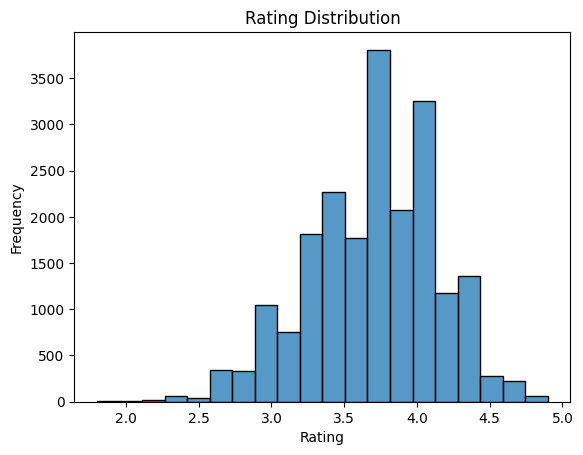

In [ ]:
sns.histplot(df['rate'],bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


In [ ]:
cuision_rating=df.groupby('cuisines')['rate'].mean().sort_values(ascending=False).head(10)
print(cuision_rating)

cuisines
Cantonese        4.600000
African          4.540000
Singaporean      4.460000
Sri Lankan       4.400000
Malaysian        4.372727
Belgian          4.350000
Bar Food         4.300000
Portuguese       4.300000
Modern Indian    4.294118
Goan             4.281250
Name: rate, dtype: float64


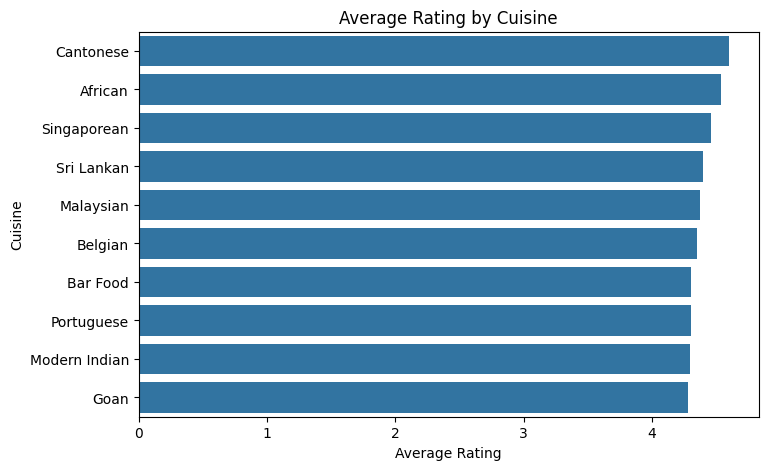

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=cuision_rating.values,y=cuision_rating.index)
plt.title("Average Rating by Cuisine")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.show()

In [ ]:
#split cuisines
cuisines_series=df['cuisines'].dropna().str.split(',')

#flatten list
all_cuisines=cuisines_series.explode()

#count
top_cuisines=all_cuisines.value_counts().head(10)
print(top_cuisines)

cuisines
North Indian    3494
Chinese         2521
South Indian    1393
Fast Food       1321
Biryani         1059
Desserts         946
Cafe             916
Continental      842
Beverages        799
Italian          604
Name: count, dtype: int64


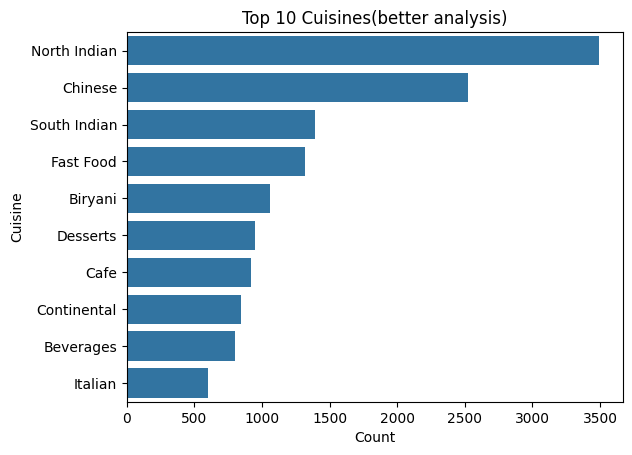

In [ ]:
sns.barplot(x=top_cuisines.values,y=top_cuisines.index)
plt.title("Top 10 Cuisines(better analysis)")
plt.xlabel("Count")
plt.ylabel("Cuisine")
plt.show()

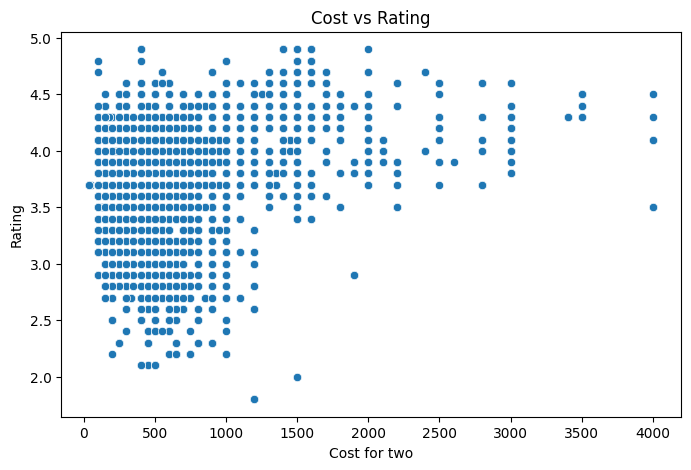

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['approx_cost(for two people)'],y=df['rate'])
plt.title("Cost vs Rating")
plt.xlabel("Cost for two")
plt.ylabel("Rating")
plt.show()

In [ ]:
# Clean rate column
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean cost column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

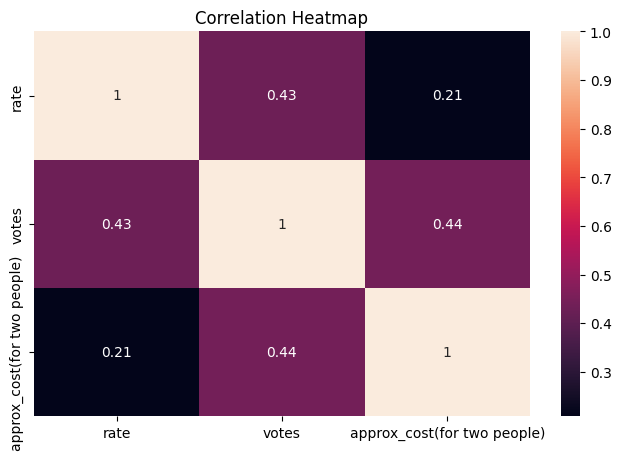

In [ ]:
corr = df[['rate','votes','approx_cost(for two people)']].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install wordcloud

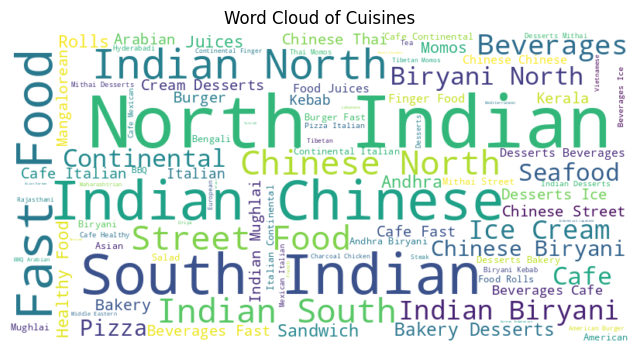

In [ ]:
from wordcloud import WordCloud
text = ' '.join(df['cuisines'].dropna().astype(str))
wc=WordCloud(width=800,height=400,background_color='white').generate(text)
plt.figure(figsize=(8,5))
plt.imshow(wc,interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cuisines")
plt.show()

In [ ]:
# Simplify cuisines (keep only first cuisine)
df['cuisines'] = df['cuisines'].fillna('Unknown')
df['cuisines'] = df['cuisines'].astype(str)
df['cuisines'] = df['cuisines'].apply(lambda x: x.split(',')[0])

# Reduce locations (keep top 10 locations only)
df['location'] = df['location'].fillna('Unknown')
top_locations = df['location'].value_counts().nlargest(10).index

df['location'] = df['location'].apply(
    lambda x: x if x in top_locations else 'other'
)

# Reduce dataset size safely
df = df.sample(n=min(len(df), 10000), random_state=42)

# Check result
print("Dataset Shape:", df.shape)
print(df[['cuisines', 'location']].head())

Dataset Shape: (182, 17)
         cuisines            location
21           Cafe        Banashankari
57          Asian        Banashankari
308  North Indian  Kumaraswamy Layout
205         Pizza        Banashankari
296  North Indian           Jayanagar


In [ ]:
# Re-clean 'approx_cost(for two people)' after sampling
df['approx_cost(for two people)']=df['approx_cost(for two people)'].astype(str)
#Remove commas
df['approx_cost(for two people)']=df['approx_cost(for two people)'].str.replace(',','')
# remove ₹ symbol if present
df['approx_cost(for two people)']=df['approx_cost(for two people)'].str.replace('₹','')
#convert to numeric
df['approx_cost(for two people)']=pd.to_numeric(df['approx_cost(for two people)'],errors='coerce')

# Drop rows where 'approx_cost(for two people)' became NaN after conversion
df=df.dropna(subset=['approx_cost(for two people)'])

In [ ]:
x=df[['votes','approx_cost(for two people)','location','cuisines']]
y=df['rate']

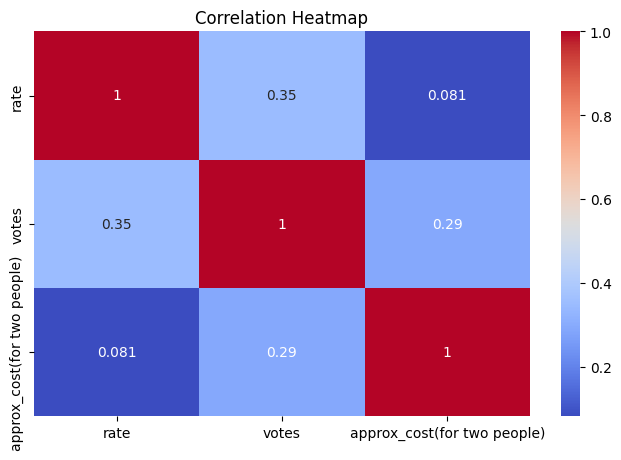

In [ ]:
# Clean rate column
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean cost column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

# Correlation Heatmap
corr = df[['rate', 'votes', 'approx_cost(for two people)']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Train-Test Split

In [ ]:
x=df[['votes','approx_cost(for two people)','location','cuisines']]
y=df['rate']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score

Preprocessing -

In [ ]:
from sklearn.compose import ColumnTransformer
numeric_features=['votes','approx_cost(for two people)']
categorical_features=['location','cuisines']
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numeric_features),
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)
    ]
)

Model(optimized)

In [ ]:
# Clean rate column
df['rate'] = df['rate'].astype(str)

# Remove '/5'
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

# Replace invalid values with NaN
df['rate'] = df['rate'].replace(['NEW', '-', 'nan'], np.nan)

# Convert to float
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Remove rows with missing rate
df = df.dropna(subset=['rate'])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ('preprocessor' , preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        random_state=42
    ))
])

train model

In [ ]:
# Train the model
model.fit(x_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['votes',
                                                   'approx_cost(for two '
                                                   'people)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['location', 'cuisines'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, n_estimators=50,
                                       random_state=42))])

In [ ]:
# Make predictions
y_pred = model.predict(x_test)

Evaluation -

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Root Mean Squared Error: 0.35013506492882984
R-squared: -0.1314005507302689


**Key Insights -**

the analysis led to several impotant insights:

Most resturants have ratings between 3.5 and 4.5
indicating generally good quality.
papular cuisines include North indian , Chinese, and Fast Food.
Certain locations have a higher concentration of restaurants showing business hotspots.
cost has a weak correction with ratings, meaning expensive esturants are not always better.
Resturants with more votes tend to have slightly higher ratings due to higher customer engagement.



**Recommendations for Alfido Tech Platform-**


Improve learning materials with more practical examples and tutorials.

2.   

Provide better mentor support for project guidance.
Add more advanced courses in AI, Data Science, and Cloud Computing.
Conduct regular assessments and provide feedback.
Enhance the user interface for a better learning experience.
Offer career guidance, resume building, and interview preparation.
Ensure timely issuance of certificates after internship completion